# Experiment 10: Fashion MNIST Clothing Classifier using CNN

## Aim
Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.

## Theory
The Fashion MNIST dataset contains 70,000 grayscale images (28×28) of 10 clothing categories:

| Label | Category |
|-------|----------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

We will build a CNN (Convolutional Neural Network) to classify these images.

## Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Step 2: Load the Fashion MNIST Dataset

In [2]:
# Load dataset - automatically downloads if not present
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Class names for the 10 categories
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Number of classes:", len(class_names))
print("\nClasses:", class_names)
print("\nPixel value range:", X_train.min(), "-", X_train.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (60000, 28, 28)
Testing set shape: (10000, 28, 28)
Number of classes: 10

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Pixel value range: 0 - 255


## Step 3: Visualize Sample Images

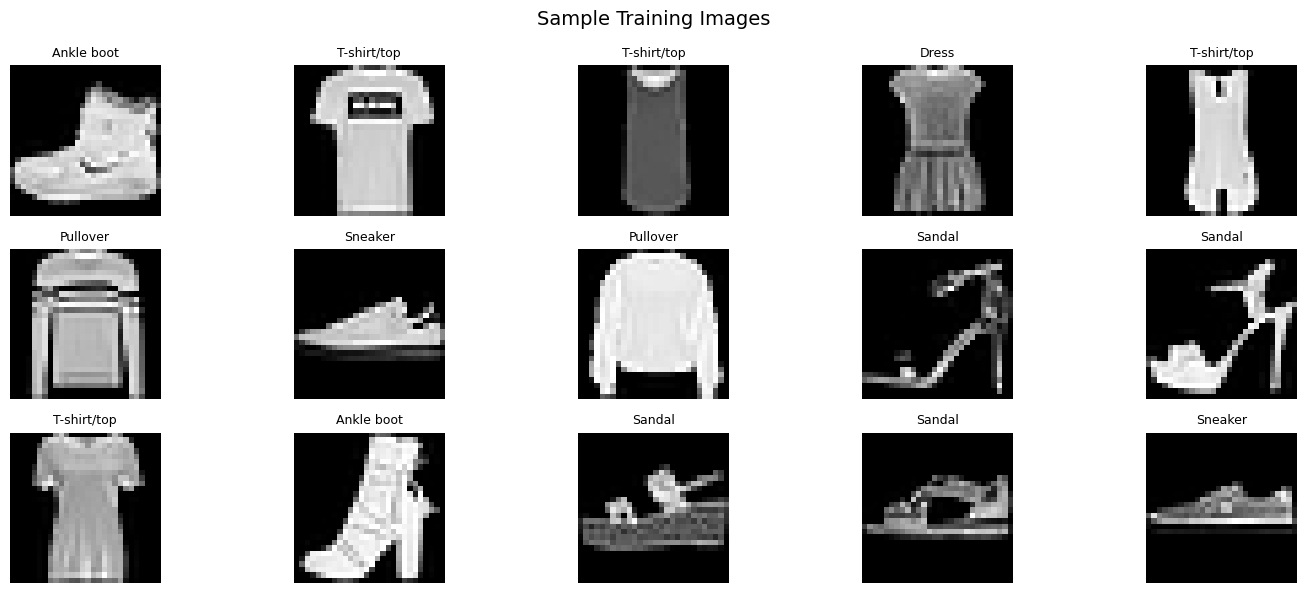

In [3]:
# Display first 15 images from the training set
plt.figure(figsize=(15, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## Step 4: Preprocess the Data

In [4]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN: add channel dimension (28, 28) -> (28, 28, 1)
# CNN expects 4D input: (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("After preprocessing:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Pixel value range:", X_train.min(), "-", X_train.max())

After preprocessing:
X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
Pixel value range: 0.0 - 1.0


## Step 5: Build the CNN Model

### Architecture:
```
Input (28×28×1)
    ↓
Conv2D(32, 3×3, relu) → MaxPool(2×2)
    ↓
Conv2D(64, 3×3, relu) → MaxPool(2×2)
    ↓
Conv2D(128, 3×3, relu)
    ↓
Flatten → Dropout(0.5)
    ↓
Dense(128, relu) → Dropout(0.3)
    ↓
Dense(10, softmax) → Output
```

In [5]:
# Build CNN Model
model = Sequential([
    # Conv Block 1: 32 filters of size 3x3
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Conv Block 2: 64 filters of size 3x3
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Conv Block 3: 128 filters of size 3x3
    Conv2D(128, (3, 3), activation='relu'),

    # Flatten and Dense layers
    Flatten(),
    Dropout(0.5),               # Prevents overfitting
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 output classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile the Model

In [6]:
# Compile with Adam optimizer and sparse categorical crossentropy
# sparse_categorical_crossentropy is used because labels are integers (0-9)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print("Optimizer: Adam")
print("Loss: Sparse Categorical Crossentropy")
print("Metrics: Accuracy")

Model compiled successfully!
Optimizer: Adam
Loss: Sparse Categorical Crossentropy
Metrics: Accuracy


## Step 7: Train the Model

In [7]:
# Train the model
EPOCHS = 10
BATCH_SIZE = 64

print(f"Training for {EPOCHS} epochs with batch size {BATCH_SIZE}...\n")

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # Use 20% of training data for validation
    verbose=1
)

Training for 10 epochs with batch size 64...

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - accuracy: 0.7519 - loss: 0.6677 - val_accuracy: 0.8424 - val_loss: 0.4178
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.8432 - loss: 0.4300 - val_accuracy: 0.8721 - val_loss: 0.3362
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 77s 57ms/step - accuracy: 0.8667 - loss: 0.3652 - val_accuracy: 0.8765 - val_loss: 0.3304
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 58ms/step - accuracy: 0.8809 - loss: 0.3275 - val_accuracy: 0.8894 - val_loss: 0.2905
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.8885 - loss: 0.3057 - val_accuracy: 0.8967 - val_loss: 0.2739
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - accuracy: 0.8958 - loss: 0.2856 - val_accuracy: 0.9041 - val_loss: 0.2570
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 57ms/step - accuracy: 0.9036 - loss: 0.2675 - val_accuracy: 0.9037 - val_loss: 0.2581
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 

## Step 8: Plot Training History

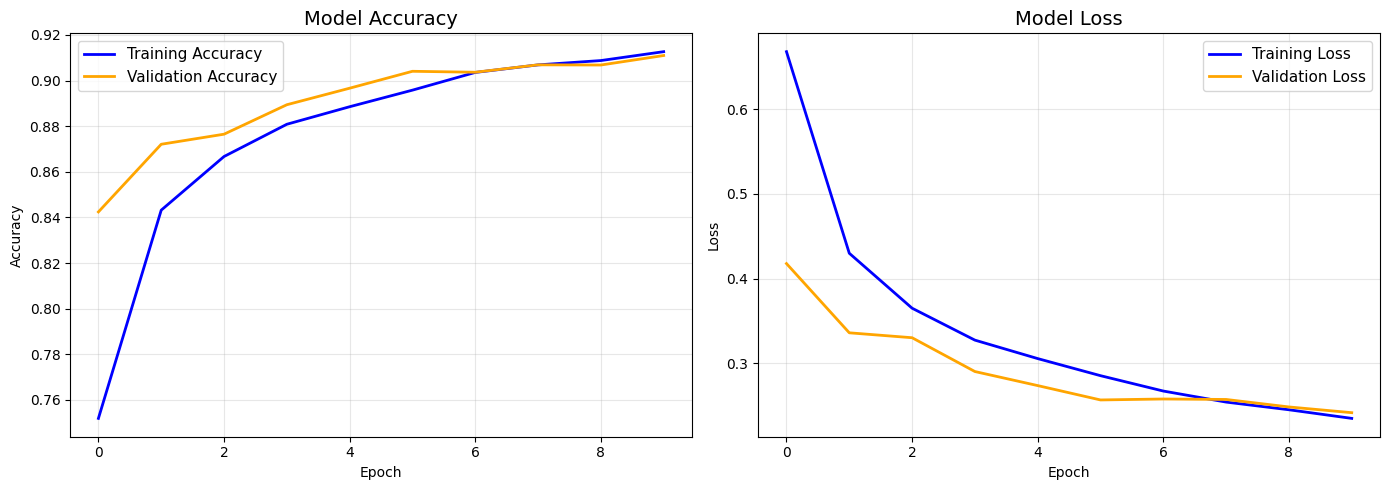

In [8]:
# Plot Accuracy and Loss curves
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9: Evaluate on Test Set

In [9]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=" * 50)
print(" Model Evaluation on Test Set")
print("=" * 50)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print("=" * 50)

 Model Evaluation on Test Set
Test Loss:     0.2554
Test Accuracy: 0.9072 (90.72%)


## Step 10: Classification Report

In [10]:
# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Print classification report
print("\nClassification Report:")
print("=" * 65)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.85      0.86      0.86      1000
       Dress       0.91      0.92      0.91      1000
        Coat       0.86      0.84      0.85      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.73      0.71      0.72      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## Step 11: Confusion Matrix

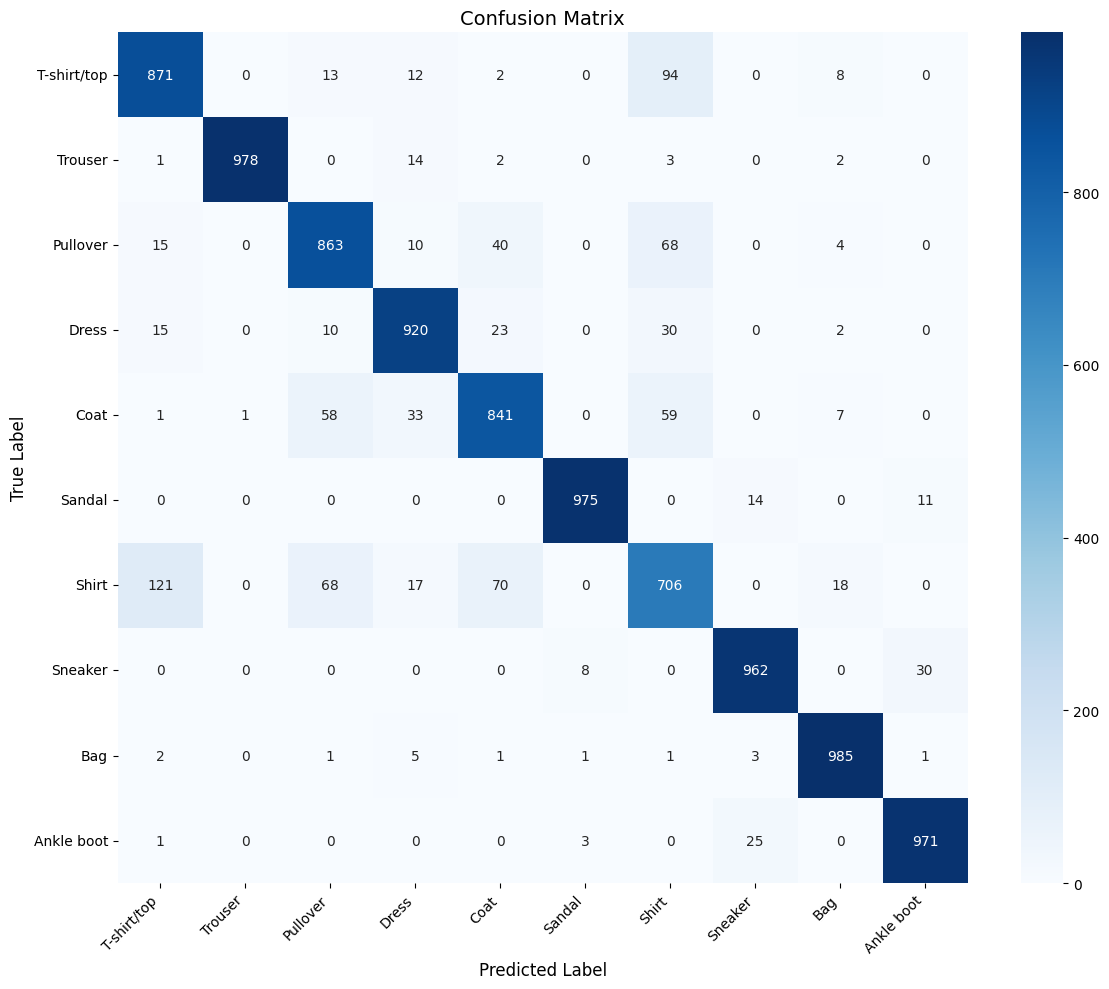

In [11]:
# Create and plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 12: Visualize Predictions

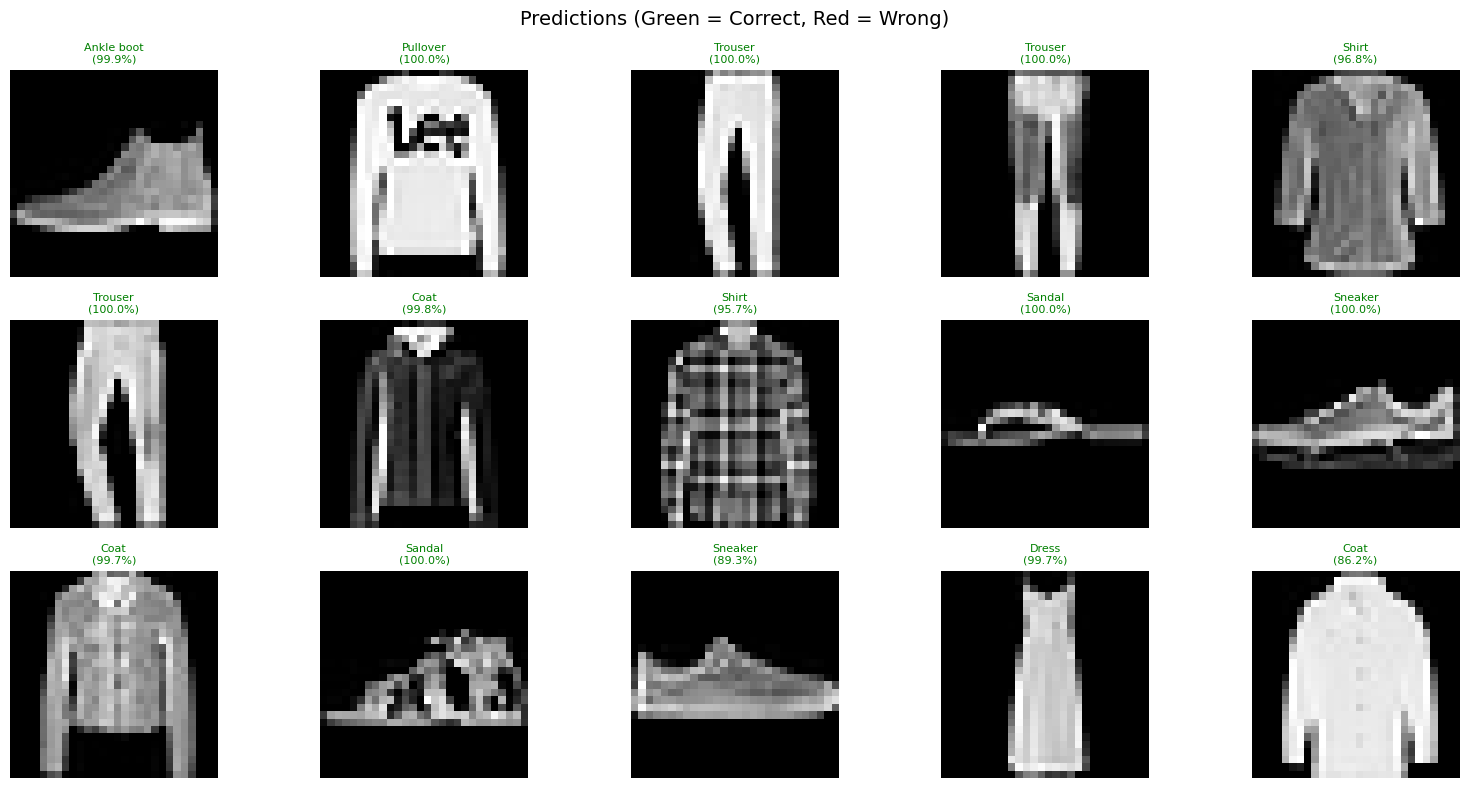

In [12]:
# Show predictions on test images
plt.figure(figsize=(16, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    pred_label = class_names[y_pred_classes[i]]
    true_label = class_names[y_test[i]]
    confidence = np.max(y_pred[i]) * 100

    # Green title if correct, Red if wrong
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"{pred_label}\n({confidence:.1f}%)", color=color, fontsize=8)
    plt.axis('off')

plt.suptitle('Predictions (Green = Correct, Red = Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

## Step 13: Predict on a Single Image

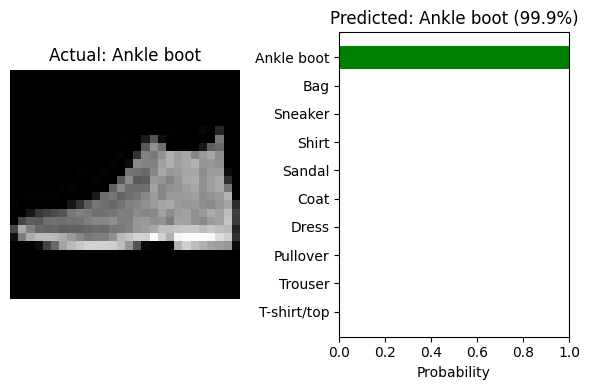


Predicted: Ankle boot
Actual:    Ankle boot
Confidence: 99.92%


In [13]:
# Predict on a single test image
test_index = 0

single_image = X_test[test_index].reshape(1, 28, 28, 1)
prediction = model.predict(single_image, verbose=0)

predicted_class = class_names[np.argmax(prediction)]
actual_class = class_names[y_test[test_index]]
confidence = np.max(prediction) * 100

plt.figure(figsize=(6, 4))
plt.subplot(1, 2, 1)
plt.imshow(X_test[test_index].reshape(28, 28), cmap='gray')
plt.title(f"Actual: {actual_class}")
plt.axis('off')

plt.subplot(1, 2, 2)
colors = ['green' if i == np.argmax(prediction) else 'lightgray' for i in range(10)]
plt.barh(class_names, prediction[0], color=colors)
plt.title(f"Predicted: {predicted_class} ({confidence:.1f}%)")
plt.xlabel('Probability')
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nPredicted: {predicted_class}")
print(f"Actual:    {actual_class}")
print(f"Confidence: {confidence:.2f}%")

## Conclusion

We successfully built a CNN classifier for the Fashion MNIST dataset that classifies clothing items into 10 categories with high accuracy (~90-92%).

### Key Observations:
- CNN achieves ~90-92% test accuracy on Fashion MNIST
- Categories like **Trouser** and **Bag** are easiest to classify
- **Shirt** and **T-shirt** are often confused with each other
- Dropout layers help prevent overfitting
- Data normalization (0-1) improves training convergence

---

## Viva Questions and Answers

**Q1: What is Fashion MNIST?**  
A: A dataset of 70,000 grayscale 28×28 images of 10 clothing categories. It is a drop-in replacement for the original MNIST digit dataset.

**Q2: Why use CNN instead of a regular neural network?**  
A: CNNs use convolutional layers that can detect spatial features (edges, textures, shapes) in images. Regular DNNs treat each pixel independently and lose spatial information.

**Q3: What does Conv2D do?**  
A: Conv2D applies a set of learnable filters (kernels) to the input image to extract features like edges, corners, and textures.

**Q4: What is MaxPooling?**  
A: MaxPooling reduces the spatial dimensions by taking the maximum value in each pooling window. It reduces computation and helps with translation invariance.

**Q5: Why normalize pixel values to 0-1?**  
A: Normalization helps the neural network train faster and converge better by keeping values in a small range.

**Q6: What is Dropout?**  
A: Dropout randomly disables neurons during training to prevent overfitting. It forces the network to learn more robust features.

**Q7: What is Softmax?**  
A: Softmax converts raw output scores into probabilities that sum to 1. The class with the highest probability is the prediction.

**Q8: What is sparse_categorical_crossentropy?**  
A: A loss function used when labels are integers (not one-hot encoded). It measures the difference between predicted probabilities and actual class.

**Q9: What is a confusion matrix?**  
A: A table showing correct and incorrect predictions for each class. Diagonal values are correct predictions; off-diagonal are misclassifications.

**Q10: How can accuracy be improved?**  
A: Data augmentation, deeper networks, batch normalization, learning rate scheduling, or using transfer learning with pre-trained models.